# Extraction of Lipids from Foods (Soxhlet / Solvent Extraction)

**Objective:** Calculate percent fat content of food samples from pre- and
post-extraction weights, and classify each sample by fat category.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sample_data/extraction_weights.csv")
df

,sample_id,dry_weight_g,fat_extracted_g
0,Peanuts,5.02,2.41
1,Oats,5.10,0.34
2,Spinach(dry),5.00,0.08
3,Cheddar,5.05,1.68


## Calculate percent fat and categorise

In [2]:
df["percent_fat"] = (df.fat_extracted_g / df.dry_weight_g * 100).round(1)

def categorize(pct):
    if pct < 5: return "Low-fat"
    elif pct <= 20: return "Moderate-fat"
    return "High-fat"

df["category"] = df.percent_fat.apply(categorize)
df

,sample_id,dry_weight_g,fat_extracted_g,percent_fat,category
0,Peanuts,5.02,2.41,48.0,High-fat
1,Oats,5.10,0.34,6.7,Moderate-fat
2,Spinach(dry),5.00,0.08,1.6,Low-fat
3,Cheddar,5.05,1.68,33.3,High-fat


## Visualise fat content by sample

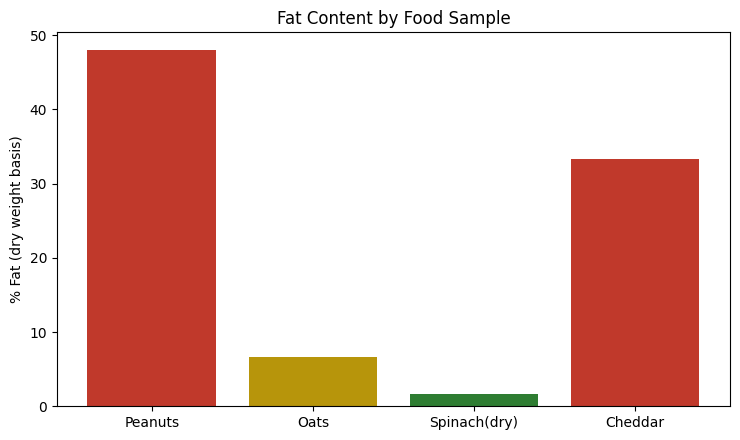

In [3]:
color_map = {"Low-fat": "#2E7D32", "Moderate-fat": "#B7950B", "High-fat": "#C0392B"}
colors = df.category.map(color_map)

plt.figure(figsize=(7.5, 4.5))
plt.bar(df.sample_id, df.percent_fat, color=colors)
plt.ylabel("% Fat (dry weight basis)")
plt.title("Fat Content by Food Sample")
plt.tight_layout()
plt.savefig("lipid_extraction_plot.png", dpi=150)
plt.show()

## Summary

Fat content varied widely across the sample set, from under 2% in the dried
spinach sample to nearly 50% in peanuts, illustrating the wide range of fat
content across food categories that solvent extraction is used to quantify
for nutritional labelling and food science applications.
